In [1]:
import numpy as np
from netCDF4 import Dataset
import matplotlib.pyplot as plt
#import cartopy.crs as crs
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature
from cartopy.feature import NaturalEarthFeature
import cartopy.crs as ccrs
from datetime import datetime, timedelta
from metpy.units import units
from metpy.calc import dewpoint_from_specific_humidity, relative_humidity_from_specific_humidity, wind_speed, specific_humidity_from_mixing_ratio
import pyart
from wrf import getvar
import haversine
from metpy.interpolate import log_interpolate_1d, interpolate_1d
from pyproj import Geod


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
g = Geod(ellps='sphere')

In [3]:
#Basic settings for the UAS transects
wspd_thresh = 20 #wind speed cutoff for UAS ops, in m/s
drone_spd = 30 #UAS cruising speed, in m/s
begin_time1 = 10800 #Baseline time (in seconds since 0 UTC)
ascent_rate = 3 #Ascent / descent rate for the profiles (in m/s)
z_res = 50 #profile vertical resolution (in m)
prof_top = 100 #Profile top / UAS cruising altitude (in m)
x_int = 150 #interval between obs along transects (in s)
delay = 60 #delay in seconds between profiles and transects

#Datetims start info
#dt = datetime(2022,9,15,10)
dt = datetime(2022,7,19,10)
#dt = datetime(2021,6,4,10)

#Start day
#st_day = 154024
st_day = 153966
#st_day = 153556

ncfile1 = Dataset('/glade/work/mawilson/DART_mpd/observations/utilities/threed_sphere/obs_epoch_100mIOP4.nc')
#ncfile1 = Dataset('/glade/work/mawilson/DART_mpd/observations/utilities/threed_sphere/obs_epoch_100mJUNE.nc')

location = ncfile1.variables['location'][:]
qc = ncfile1.variables['qc'][:]
obstype = ncfile1.variables['obs_type'][:]
obstypemd = ncfile1.variables['ObsTypesMetaData'][:]
obs_val = ncfile1.variables['observations'][:]
which_vert = ncfile1.variables['which_vert'][:]

print(obstype)
qc_new = []
for i in range(len(qc)):
    qc_d = qc[i][0]
    qc_new.append(qc_d)
qc_new = np.asarray(qc_new)

otype1 = 142
loc_T = location[obstype==otype1, :]
qc_T = qc_new[obstype==otype1]
obs_T = obs_val[obstype==otype1, :]
lons_T = loc_T[:,0]
lats_T = loc_T[:,1]

lons_T[lons_T > 180] = lons_T[lons_T > 180] - 360

prof_lons = lons_T[np.unique(lons_T, return_index=True)[1]]
prof_lats = lats_T[np.unique(lons_T, return_index=True)[1]]

[142 105 106 ...  26  27  28]


In [4]:

#Make an array where the starting point for each route is CVG and the end is every other ASOS in the domain
lons_start = np.asarray([-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55])
lats_start = np.asarray([39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21])
lons_end = np.asarray([-84.93, -84.55, -84.09, -84.15, -84.52, -84.94, -85.21, -85.29])
lats_end = np.asarray([39.41, 39.48, 39.47, 38.92, 38.86, 38.95, 39.19, 38.86])

lons_start = np.asarray([-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55,-84.55])
lats_start = np.asarray([39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21,39.21])
lons_end = np.asarray([-84.93, -84.55, -84.09, -84.15, -84.52, -84.94, -85.21, -85.29,
                      -85.26000214,-84.77999878,-84.66999817,-84.51999664,-84.41999817,-84.40000153,-84.25,-84.23000336,-84.22000122])
lats_end = np.asarray([39.41, 39.48, 39.47, 38.92, 38.86, 38.95, 39.19, 38.86,
                      39.34999847,39.25,39.04000092,39.36000061,39.09999847,39.52999878,39.45999908,39.59999847,39.08000183])

# lons_start = np.asarray([-84.67229, -84.67229, -84.67229, -84.67229, -84.67229, -84.67229, -84.67229, -84.67229, -84.67229, -84.67229])
# lats_start = np.asarray([39.04456, 39.04456, 39.04456, 39.04456, 39.04456, 39.04456, 39.04456, 39.04456, 39.04456, 39.04456])
# lons_end = np.asarray([-84.41583, -84.2102, -84.7743, -84.25184, -84.78436, -85.25843, -85.4655, -83.77917, -84.39530, -83.7434])
# lats_end = np.asarray([39.10583, 39.0784, 39.2589, 39.46217, 39.50225, 39.34313, 38.7589, 39.42833, 39.53100, 38.5418])
st_ids = ['Site 1', 'Site 2', 'Site 3', 'Site 4', 'Site 5', 'Site 6', 'Site 7', 'Site 8',
          'Site 9', 'Site 10', 'Site 11', 'Site 12', 'Site 13', 'Site 14', 'Site 15', 'Site 16', 'Site 17']
#Get distance between the points

#Make a definition for this section
#Inputs: start and end point, obs_interval (in seconds), drone speed (in m/s)
#Outputs: lat / lons and times (since transect start, in seconds) for UAS transect
def get_transect_points(lat_d, lon_d, lat_c, lon_c, ob_int, drone_spd, start_time, height):
    points=[]
    station=[]
    points.append((lat_d,lon_d))
    station.append((lat_c,lon_c))
    dist = haversine.haversine_vector(station,points)
    #Get the bearing between the cities
    distance_track = g.inv(lon_d, lat_d,
                           lon_c, lat_c)
    bearing = distance_track[0]
    if bearing < 0:
        bearing = 360 + bearing
    print(dist)
    print((dist*1000)/drone_spd)
    print(((dist*1000)/drone_spd)/3600)
    print(((dist*1000)/drone_spd)/ob_int)
    print(int(((dist*1000)/drone_spd)/ob_int))
    
    #Extrapolate forward to get points along the path every 5 minutes
    path_lat = []
    path_lon = []
    lond1 = lon_d
    latd1 = lat_d
    time_path = []
    time_i = start_time
    for i in range(int(((dist*1000)/drone_spd)/ob_int)):
        prj_lon, prj_lat, prj_bear = g.fwd(lond1, latd1, bearing, drone_spd*ob_int)
        path_lat.append(prj_lat)
        path_lon.append(prj_lon)
        time_i = time_i + ob_int
        time_path.append(time_i)
        lond1 = prj_lon
        latd1 = prj_lat
    path_z = np.zeros((len(path_lon)))
    path_z[:] = height
    return path_lon, path_lat, time_path, path_z

#Make a definition that creates the takeoff profile

def takeoff_profile(ascent_rate, resolution, top, start_time, prof_lat, prof_lon):
    uas_z = np.arange(0, top+resolution, resolution)
    #uas_time = np.arange(0, ((len(uas_z)*resolution)/ascent_rate)+(resolution/ascent_rate), resolution/ascent_rate)+start_time
    uas_time = np.arange(0, ((len(uas_z)*resolution)/ascent_rate), resolution/ascent_rate)+start_time
    uas_lat = np.zeros((len(uas_z)))
    uas_lon = np.zeros((len(uas_z)))
    uas_lat[:] = prof_lat
    uas_lon[:] = prof_lon
    print(len(uas_time), 'T')
    print(len(uas_lon), 'L')
    return uas_z, uas_time, uas_lat, uas_lon

#Make a definition for the landing profile

def landing_profile(ascent_rate, resolution, top, start_time, prof_lat, prof_lon):
    uas_z = np.arange(top-resolution, 0, resolution*-1)
    uas_time = np.arange(resolution/ascent_rate, ((len(uas_z)*resolution)/ascent_rate)+(resolution/ascent_rate), resolution/ascent_rate)+start_time
    uas_lat = np.zeros((len(uas_z)))
    uas_lon = np.zeros((len(uas_z)))
    uas_lat[:] = prof_lat
    uas_lon[:] = prof_lon
    return uas_z, uas_time, uas_lat, uas_lon

#Now run all of them

all_lons = []
all_lats = []
all_times = []
all_zs = []

for begin_time in [begin_time1, begin_time1+(2*3600), begin_time1+(4*3600), begin_time1+(6*3600)]:
    for i in range(len(lons_start)):
        tk_z, tk_time, tk_lat, tk_lon = takeoff_profile(ascent_rate, z_res, prof_top, begin_time, lats_start[i], lons_start[i])
        path_lon, path_lat, time_path, z_path = get_transect_points(lats_start[i], lons_start[i], lats_end[i], lons_end[i], x_int, drone_spd, tk_time[-1]+delay, prof_top)
        #MW 11/12/24 removing landing profiles since they're typically not used
        #ln_z, ln_time, ln_lat, ln_lon = landing_profile(ascent_rate, z_res, prof_top, time_path[-1]+delay, lats_end[i], lons_end[i])
    
        path_lon1 = np.concatenate([tk_lon, path_lon])
        path_lat1 = np.concatenate([tk_lat, path_lat])
        path_time1 = np.concatenate([tk_time, time_path])
        path_z1 = np.concatenate([tk_z, z_path])
        
        all_lons.append(path_lon1)
        all_lats.append(path_lat1)
        all_times.append(path_time1)
        all_zs.append(path_z1)
    
    for i in range(len(lons_start)):
        tk_z, tk_time, tk_lat, tk_lon = takeoff_profile(ascent_rate, z_res, prof_top, begin_time+3600, lats_end[i], lons_end[i])
        path_lon, path_lat, time_path, z_path = get_transect_points(lats_end[i], lons_end[i], lats_start[i], lons_start[i], x_int, drone_spd, tk_time[-1]+delay, prof_top)
        #MW 11/12/24 removing landing profiles since they're typically not used
        #ln_z, ln_time, ln_lat, ln_lon = landing_profile(ascent_rate, z_res, prof_top, time_path[-1]+delay, lats_end[i], lons_end[i])
    
        path_lon1 = np.concatenate([tk_lon, path_lon])
        path_lat1 = np.concatenate([tk_lat, path_lat])
        path_time1 = np.concatenate([tk_time, time_path])
        path_z1 = np.concatenate([tk_z, z_path])
        
        all_lons.append(path_lon1)
        all_lats.append(path_lat1)
        all_times.append(path_time1)
        all_zs.append(path_z1)
    
all_lons1 = np.concatenate(all_lons)
all_lats1 = np.concatenate(all_lats)
all_times1 = np.concatenate(all_times)
all_zs1 = np.concatenate(all_zs)


3 T
3 L
[39.54009533]
[1318.00317753]
[0.36611199]
[8.78668785]
8
3 T
3 L
[30.02267166]
[1000.7557221]
[0.2779877]
[6.67170481]
6
3 T
3 L
[48.9973507]
[1633.24502344]
[0.45367917]
[10.88830016]
10
3 T
3 L
[47.24869554]
[1574.95651815]
[0.43748792]
[10.49971012]
10
3 T
3 L
[39.00444108]
[1300.14803594]
[0.36115223]
[8.66765357]
8
3 T
3 L
[44.37412161]
[1479.1373871]
[0.4108715]
[9.86091591]
9
3 T
3 L
[56.9155478]
[1897.18492678]
[0.52699581]
[12.64789951]
12
3 T
3 L
[74.83140606]
[2494.38020215]
[0.69288339]
[16.62920135]
16
3 T
3 L
[63.06255346]
[2102.08511543]
[0.58391253]
[14.01390077]
14
3 T
3 L
[20.30369119]
[676.78970623]
[0.18799714]
[4.51193137]
4
3 T
3 L
[21.55166716]
[718.38890525]
[0.19955247]
[4.78925937]
4
3 T
3 L
[16.87803586]
[562.60119534]
[0.15627811]
[3.75067464]
3
3 T
3 L
[16.59108116]
[553.03603858]
[0.15362112]
[3.68690692]
3
3 T
3 L
[37.84645531]
[1261.5485104]
[0.35043014]
[8.4103234]
8
3 T
3 L
[37.92712668]
[1264.23755585]
[0.3511771]
[8.42825037]
8
3 T
3 L
[51.3

/glade/derecho/scratch/mawilson/tmp/ipykernel_48423/322109410.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(int(((dist*1000)/drone_spd)/ob_int))
/glade/derecho/scratch/mawilson/tmp/ipykernel_48423/322109410.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  for i in range(int(((dist*1000)/drone_spd)/ob_int)):


In [5]:
#print(distance_track)

In [6]:
#print(prj_lon, prj_lat)

In [7]:
# print(path_z1)
# print(path_time1)
print(all_times1)

[10800.         10816.66666667 10833.33333333 ... 36843.33333333
 36993.33333333 37143.33333333]


In [8]:
#print(lon_c, lat_c)

In [9]:
#Make a map to show the domain
lati = 37.15
loni = -84.00

# lat = 39.4
# lon = -101.80
cenlat1 = float(lati)
cenlon1 = float(loni)

# LL1 = (cenlon1-10.,cenlat1-4.0,ccrs.PlateCarree())
# UR1 = (cenlon1+6.,cenlat1+8.0,ccrs.PlateCarree())

# #Set up our map projection

crs = ccrs.LambertConformal(central_longitude=-100.0, central_latitude=45.0)

#Read in files for state and county boundaries
fname = 'cb_2016_us_county_20m/cb_2016_us_county_20m.shp'
fname2 = 'cb_2016_us_state_20m/cb_2016_us_state_20m.shp'
counties = ShapelyFeature(Reader(fname).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')
states = ShapelyFeature(Reader(fname2).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')

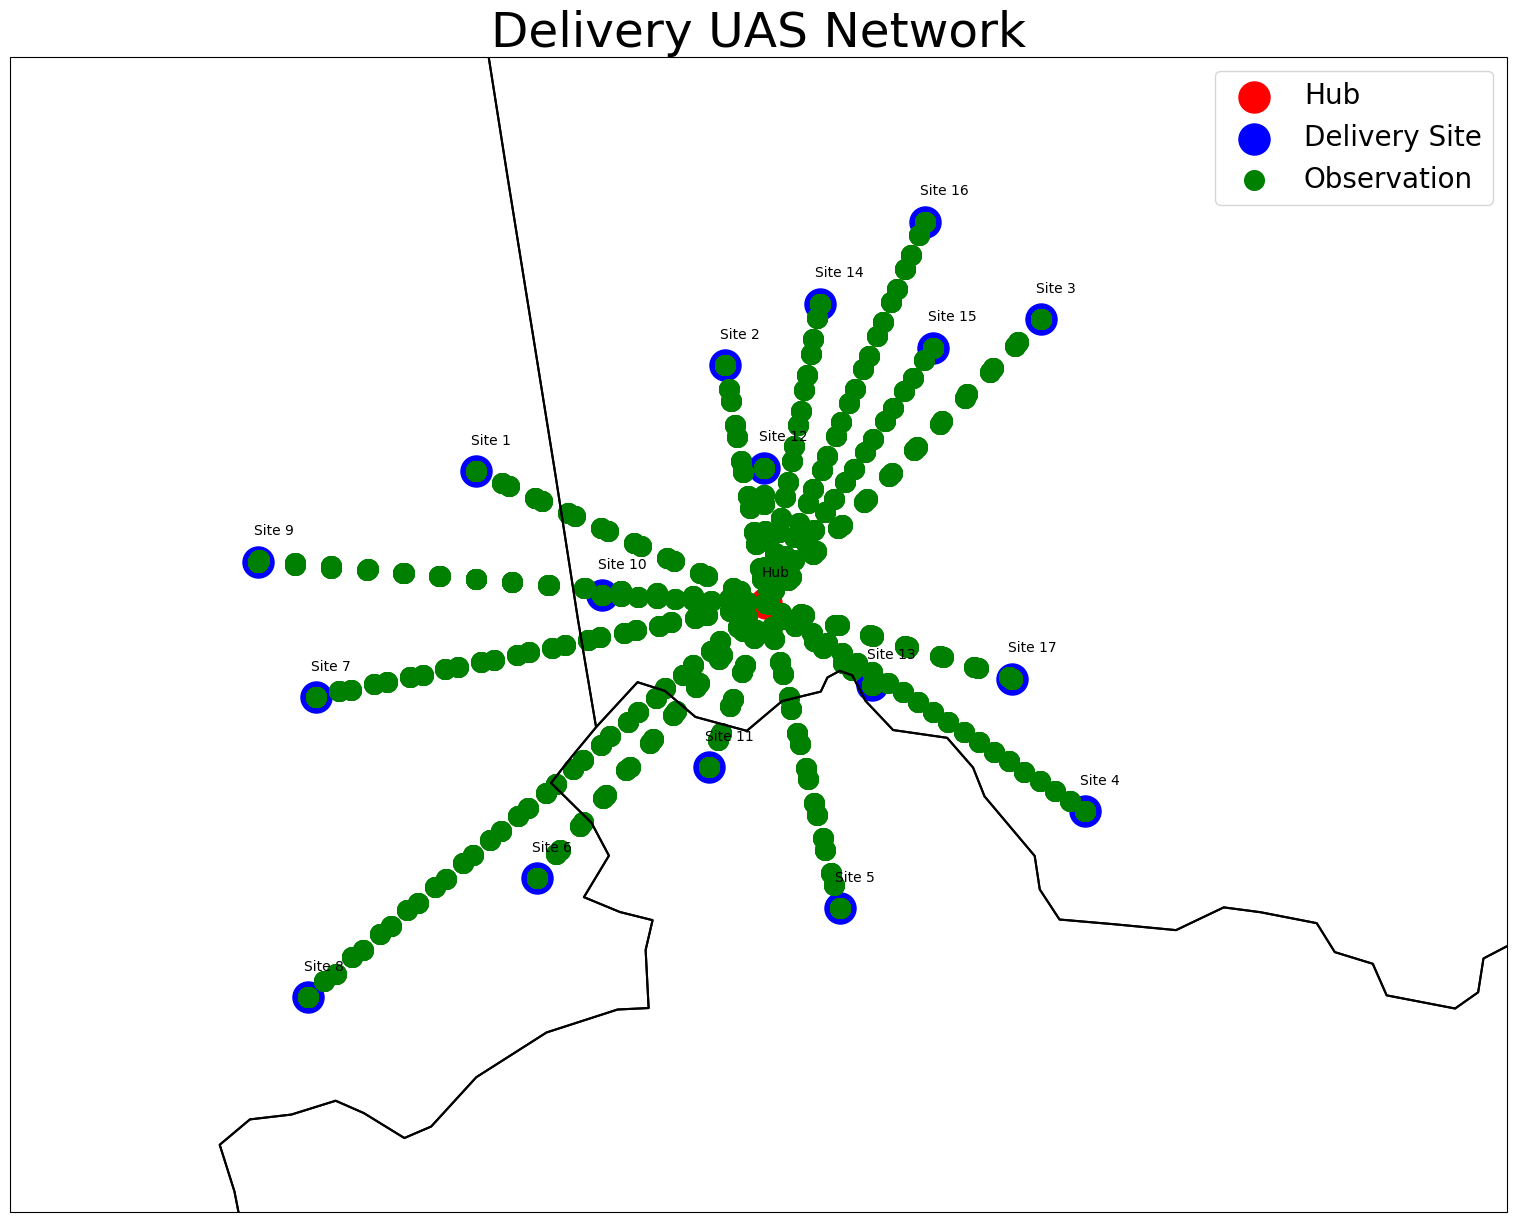

In [10]:
cenlon2 = cenlon1+0.2
cenlat2 = cenlat1+1.5

LL2 = (cenlon2-1.75,cenlat2+0.0,ccrs.PlateCarree())
UR2 = (cenlon2+0.2,cenlat2+1.05,ccrs.PlateCarree())

figure_mosaic = """
D
"""

fig, axes = plt.subplot_mosaic(mosaic=figure_mosaic, figsize=(30,15), subplot_kw={'projection': crs})
prslev = [0,0.25,0.5,1.0,2.0,3.0,6.0]
#axes['D'].coastlines('50m',edgecolor='white',linewidth=0.75)
axes['D'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['D'].add_feature(states,edgecolor='k',linewidth=1.5,zorder=4)
plt.scatter(lons_start[0], lats_start[0], c='r', s=500, label='Hub', transform=ccrs.PlateCarree())
plt.scatter(lons_end, lats_end, c='b', s=500, label='Delivery Site', transform=ccrs.PlateCarree())
#plt.scatter(path_lon, path_lat, c='g', s=200, transform=ccrs.PlateCarree())
plt.scatter(all_lons1, all_lats1, c='g', s=200, label='Observation', transform=ccrs.PlateCarree())
for i in range(len(lons_end)):
    plt.text(lons_end[i], lats_end[i]+0.03, st_ids[i], transform=ccrs.PlateCarree())
plt.text(lons_start[0], lats_start[0]+0.03, 'Hub', transform=ccrs.PlateCarree())
plt.title('Delivery UAS Network', size=35)
plt.legend(fontsize=20)
#plt.savefig('NewUASNetwork.png', bbox_inches='tight')

In [11]:
print(len(all_lons1)*4)

6144


In [12]:
#Put times in DART format, convert everything to go into the obs_seq file
uas_times2 = (all_times1/86400) + st_day

In [ ]:
#Obs types for the UAS obs. Change once we have this implemented in DART
otype_T = 123
otype_q = 67
otype_u = 121
otype_v = 122

#NOTE: all error values listed here are * squared * (so for an error of 2.0 K, list 4.0 K here)

# #Errors for UAS obs
oerr_T = 0.25
oerr_q = 0.25
oerr_u = 1.0
oerr_v = 1.0

#2X Errors for UAS obs
# oerr_T = 1.0
# oerr_q = 1.0
# oerr_u = 4.0
# oerr_v = 4.0

otype_s = []
obs_s = []
lon_s = []
lat_s = []
elev_s = []
error_s = []
time_s = []

#minute_range = np.arange(180,245,5)
#minute_range = np.arange(595,605,5)

otype_s = []
obs_s = []
lon_s = []
lat_s = []
elev_s = []
error_s = []
time_s = []

minute_range = np.arange(480,605,5)
#minute_range = np.arange(180,240,5)
#minute_range = np.arange(595,605,5)

for mins in minute_range:
    #dt_start = datetime(2022,9,15,0,0)
    dt_start = datetime(2022,7,19,0,0)
    #dt_start = datetime(2021,6,4,0,0)
    
    dt = dt_start + timedelta(minutes=int(mins))
    print(dt)
    #wrfout = Dataset('/glade/derecho/scratch/mawilson/20210604_newcase/nature_100IOP6/final_nature/wrfout_d02_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':'+str(dt.isoformat()[14:16])+':00')
    #wrfout = Dataset('/glade/derecho/scratch/mawilson/20210604_newcase/nature_100IOP4/final_nature/wrfout_d02_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':'+str(dt.isoformat()[14:16])+':00')
    wrfout = Dataset('/glade/campaign/ral/aap/mawilson/nature_runs/IOP4/final_nature/wrfout_d02_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':'+str(dt.isoformat()[14:16])+':00')
    
    lon = wrfout.variables['XLONG']
    lat = wrfout.variables['XLAT']
    U10 = wrfout.variables['U10']
    V10 = wrfout.variables['U10']
    T2 = np.asarray(wrfout.variables['T2'])*units('K')
    T2F = T2 .to('degF')
    Q2 = np.asarray(wrfout.variables['Q2'])
    P2 = np.asarray(wrfout.variables['PSFC'][:]/100) * units('hPa')
    Td2 = dewpoint_from_specific_humidity(P2[0,:,:], T2[0,:,:], Q2[0,:,:]*units('kg/kg'))
    RH2 = relative_humidity_from_specific_humidity(P2[0,:,:], T2[0,:,:], Q2[0,:,:]*units('kg/kg'))
    SPD10 = wind_speed(np.asarray(U10)*units('m/s'), np.asarray(V10)*units('m/s'))
    cloud=wrfout.variables['QCLOUD']
    T_z = np.asarray(getvar(wrfout, "tk"))
    p_z = np.asarray(getvar(wrfout, "pres"))
    q_zi = np.asarray(wrfout.variables['QVAPOR'][:])
    q_z = specific_humidity_from_mixing_ratio(q_zi)
    u_z, v_z = getvar(wrfout, 'uvmet')
    u_z = np.asarray(u_z)
    v_z = np.asarray(v_z)
    z_z = np.asarray(getvar(wrfout, "height_agl"))
    z_zm = np.asarray(getvar(wrfout, "height"))
    td_z = dewpoint_from_specific_humidity(p_z*units('Pa'), T_z*units('K'), q_z*units('kg/kg')).to('K')
    
    
    #otype = 107
    #otype = 105
    #otype = 106
    #otype = 108
    #otype = 142
    otype_list = [123,67,121,122]
    for otype in otype_list:
        # loc_T2 = location[obstype==otype, :]
        # qc_T2 = qc_new[obstype==otype]
        # obs_T2 = obs_val[obstype==otype, :]
        # lons_T2 = loc_T2[:,0]
        # lats_T2 = loc_T2[:,1]
        # elev_T2 = loc_T2[:,2]
        # time_T2 = times[obstype==otype]
        # lons_T2[lons_T2 > 180] = lons_T2[lons_T2 > 180] - 360
        lons_T2 = all_lons1
        lats_T2 = all_lats1
        elev_T2 = all_zs1
        time_T2 = uas_times2
        
        #Convert WRF file time into same units as the obs_seq time
        dt_tot = (dt - datetime(1601,1,1)).total_seconds() / 86400
        time_diff = np.abs(dt_tot - time_T2)
        
        #Get obs within +- 2.5 minutes of each WRF file
        time_T3 = time_T2[time_diff<(150/86400)]
        lons_T3 = lons_T2[time_diff<(150/86400)]
        lats_T3 = lats_T2[time_diff<(150/86400)]
        elev_T3 = elev_T2[time_diff<(150/86400)]
        
        if len(time_T3)==0:
            print('NO OBS IN WINDOW')
        for k in range(len(lons_T3)):
            latp=lats_T3[k]
            lonp=lons_T3[k]
            #Get location for each ob in model land
            lon1d = np.ndarray.flatten(lon[0,:,:])
            lat1d = np.ndarray.flatten(lat[0,:,:])
            station = []
            points = []
            for i in range(len(lon1d)):
                points.append((lat1d[i],lon1d[i]))
                station.append((latp,lonp))
            dist = haversine.haversine_vector(station,points)
            dist2=dist.reshape(lon.shape[1],lon.shape[2])
            print(lon[0,:,:][np.where(dist2==np.min(dist2))])
            print(lat[0,:,:][np.where(dist2==np.min(dist2))])
            print(np.where(dist2==np.min(dist2)))
            st_xind = np.where(dist2==np.min(dist2))[0][0]
            st_yind = np.where(dist2==np.min(dist2))[1][0]
            print(elev_T3[k], 'elev')

            
            if otype == 123:
                p_point = np.concatenate([[p_z[0,st_xind,st_yind]],p_z[:,st_xind,st_yind]])
                t_point = np.concatenate([[T_z[0,st_xind,st_yind]],T_z[:,st_xind,st_yind]])
                z_point = np.concatenate([[0],z_z[:,st_xind,st_yind]])
                z_zmpoint = z_zm[0, st_xind, st_yind]
                # #Fix height of sfc points to 2m
                # if elev_T3[k] == 0.0:
                #     elev_T3[k] = 2.0
                #     print('sfc', elev_T3[k])
                #     print(z_point)
                T2_a = interpolate_1d(elev_T3[k], z_point, t_point)
                print(elev_T3[k], p_point, t_point)
                #If you want to change the error assumption, just change the scale in this line
                error = np.random.normal(loc=0.0, scale=np.sqrt(oerr_T))
                if np.abs(error/4) > (np.sqrt(oerr_T)*1.0):
                    error = (error / np.abs(error)) * (np.sqrt(oerr_T)*1.0)
                T2_b = T2_a + error/4
                print(T2_a, error/4)
                error_a = oerr_T

            if otype == 67:
                p_point = np.concatenate([[p_z[0,st_xind,st_yind]],p_z[:,st_xind,st_yind]])
                t_point = np.concatenate([[td_z[0,0,st_xind,st_yind]],td_z[0,:,st_xind,st_yind]]).magnitude
                z_point = np.concatenate([[0],z_z[:,st_xind,st_yind]])
                z_zmpoint = z_zm[0, st_xind, st_yind]
                #Fix height of sfc points to lowest model level
                # if elev_T3[k] == 0.0:
                #     elev_T3[k] = 2.0
                #     print('sfc', elev_T3[k])
                #     print(z_point)
                T2_a = interpolate_1d(elev_T3[k], z_point, t_point)
                #If you want to change the error assumption, just change the scale in this line
                error = np.random.normal(loc=0.0, scale=np.sqrt(oerr_q))
                if np.abs(error/4) > (np.sqrt(oerr_q)*1.0):
                    error = (error / np.abs(error)) * (np.sqrt(oerr_q)*1.0)
                T2_b = T2_a + error/4
                print(T2_a, error/4)
                error_a = oerr_q*4
                
            elif otype == 121:
                p_point = np.concatenate([[p_z[0,st_xind,st_yind]],p_z[:,st_xind,st_yind]])
                t_point = np.concatenate([[u_z[0,st_xind,st_yind]],u_z[:,st_xind,st_yind]])
                z_point = np.concatenate([[0],z_z[:,st_xind,st_yind]])
                z_zmpoint = z_zm[0, st_xind, st_yind]
                #Fix height of sfc points to lowest model level
                # if elev_T3[k] == 0.0:
                #     elev_T3[k] = 2.0
                #     print('sfc', elev_T3[k])
                #     print(z_point)
                T2_a = interpolate_1d(elev_T3[k], z_point, t_point)
                #If you want to change the error assumption, just change the scale in this line
                error = np.random.normal(loc=0.0, scale=np.sqrt(oerr_u))
                if np.abs(error/4) > (np.sqrt(oerr_u)*1.0):
                    error = (error / np.abs(error)) * (np.sqrt(oerr_u)*1.0)
                T2_b = T2_a + error/4
                print(T2_a, error/4)
                error_a = oerr_u
                
            elif otype == 122:
                p_point = np.concatenate([[p_z[0,st_xind,st_yind]],p_z[:,st_xind,st_yind]])
                t_point = np.concatenate([[v_z[0,st_xind,st_yind]],v_z[:,st_xind,st_yind]])
                z_point = np.concatenate([[0],z_z[:,st_xind,st_yind]])
                z_zmpoint = z_zm[0, st_xind, st_yind]
                #Fix height of sfc points to lowest model level
                # if elev_T3[k] == 0.0:
                #     elev_T3[k] = 2.0
                #     print('sfc', elev_T3[k])
                #     print(z_point)
                T2_a = interpolate_1d(elev_T3[k], z_point, t_point)
                #If you want to change the error assumption, just change the scale in this line
                error = np.random.normal(loc=0.0, scale=np.sqrt(oerr_v))
                if np.abs(error/4) > (np.sqrt(oerr_v)*1.0):
                    error = (error / np.abs(error)) * (np.sqrt(oerr_v)*1.0)
                T2_b = T2_a + error/4
                print(T2_a, error/4)
                error_a = oerr_v
            
            if np.isnan(T2_a):
                #If the observation is a nan or outside of the the interpolation bounds, skip it
                print('skipping nan ob')
                continue
        
            #Append obs to arrays for writing to obs_seq file later
            otype_s.append(otype)
            obs_s.append(T2_b)
            lon_s.append(lonp)
            lat_s.append(latp)
            elev_s.append(elev_T3[k]+z_zmpoint)
            time_s.append(time_T3[k])
            error_s.append(error_a)
            print('elevation',elev_T3[k]+z_zmpoint)

2022-07-19 08:00:00


/glade/work/mawilson/conda-envs/airplane/lib/python3.11/site-packages/metpy/calc/thermo.py:1403: RuntimeWarning: invalid value encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)


[-84.930305]
[39.40991]
(array([739]), array([388]))
0.0 elev
0.0 [97708.76   97708.76   97338.945  96969.67   96592.52   96191.375
 95769.516  95310.734  94814.34   94263.945  93657.74   92988.65
 92242.195  91418.69   90507.79   89499.2    88386.89   87161.42
 85814.01   84333.4    82708.68   80936.2    78998.5    76888.94
 74600.734  72120.34   69446.734  66570.61   63490.75   60210.957
 56733.996  53068.023  49223.848  45223.15   41091.625  36862.824
 32592.94   28345.889  24198.191  20253.53   16614.004  13348.397
 10490.75    8037.9097  5955.008 ] [295.32745 295.32745 296.59537 296.24875 296.45493 296.46823 296.32013
 296.07565 295.9469  295.9376  295.88168 295.59982 295.04492 294.29456
 293.48428 292.6096  291.765   291.0626  290.44507 289.6124  288.5831
 287.66043 286.6792  285.52216 284.23566 282.7585  281.008   279.32654
 277.67764 275.5373  272.48532 269.07825 265.81042 261.72092 257.32922
 251.78328 245.14745 238.04065 230.53438 223.0636  216.81482 211.77243
 207.96881 207.

/glade/work/mawilson/conda-envs/airplane/lib/python3.11/site-packages/metpy/calc/thermo.py:1403: RuntimeWarning: invalid value encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)


[-84.88643]
[39.386826]
(array([716]), array([422]))
100.0 elev
100.0 [97598.2    97598.2    97229.91   96858.92   96478.63   96082.67
 95663.96   95205.64   94707.44   94158.97   93554.24   92881.96
 92137.6    91314.27   90405.46   89398.5    88289.95   87066.65
 85720.63   84240.05   82625.45   80852.51   78920.25   76814.375
 74532.27   72057.95   69388.9    66517.36   63443.957  60169.203
 56698.09   53039.402  49201.45   45203.99   41072.25   36858.05
 32589.504  28340.867  24194.346  20252.379  16614.225  13348.314
 10490.157   8037.2153  5954.439 ] [296.0831  296.0831  297.18277 296.89587 296.79446 296.63315 296.45663
 296.33478 296.2529  296.1264  295.82498 295.3168  294.70987 294.01233
 293.2335  292.4135  291.753   291.0628  290.0455  289.08182 288.4809
 287.80386 287.00836 285.80032 284.21906 282.71295 280.8416  279.08047
 277.23026 275.08783 272.35092 269.00867 265.86404 261.94238 257.4689
 251.89703 245.18651 238.02449 230.57787 223.20512 216.66412 211.65144
 208.19876 20

...

[-84.85289]
[39.369736]
(array([699]), array([448]))
100.0 elev
100.0 [97697.39  97697.39  97328.2   96959.    96577.55  96174.766 95761.62
 95296.82  94801.91  94252.    93646.73  92973.305 92230.81  91407.234
 90495.42  89489.33  88377.47  87155.055 85806.766 84326.445 82701.125
 80928.555 78990.31  76879.77  74588.27  72109.73  69433.336 66559.19
 63482.754 60204.33  56730.383 53064.79  49221.793 45221.    41087.562
 36865.9   32591.84  28346.068 24199.979 20256.365 16617.562 13351.339
 10492.516  8038.693  5955.185] [295.15012 295.15012 296.82483 296.73492 296.63126 296.44498 296.32846
 296.30295 296.42023 296.36047 296.04816 295.52283 294.91214 294.2259
 293.4665  292.64557 291.72662 290.72668 289.66568 288.55362 287.80426
 287.1271  286.20245 285.01578 283.61267 282.11337 280.68823 279.24753
 277.56195 275.2756  272.42838 269.55112 266.3629  262.81854 258.0526
 252.01689 245.1277  237.98207 230.56496 223.28366 217.18803 212.29395
 207.16508 205.89328 210.29628]
[296.68369057] -0.

/glade/work/mawilson/conda-envs/airplane/lib/python3.11/site-packages/metpy/calc/thermo.py:1403: RuntimeWarning: invalid value encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)


[-84.170784]
[39.425724]
(array([759]), array([975]))
100.0 elev
100.0 [98181.5   98181.5   97807.49  97432.56  97052.36  96652.195 96231.625
 95766.414 95266.28  94717.484 94107.54  93429.58  92678.63  91846.78
 90928.69  89913.91  88794.28  87563.37  86205.33  84716.75  83076.945
 81286.57  79330.51  77203.266 74891.336 72390.87  69692.71  66795.48
 63695.45  60394.176 56891.625 53197.785 49327.676 45300.99  41145.652
 36898.04  32611.54  28353.26  24202.697 20258.635 16618.953 13352.291
 10493.279  8039.183  5955.174] [294.14923 294.14923 295.35617 295.19385 294.9447  295.0721  295.69745
 296.0857  296.20343 296.05313 295.69266 295.20398 294.63947 294.0158
 293.3092  292.8346  292.4636  291.72687 290.78012 289.6136  288.19226
 286.533   285.5821  284.91275 283.8477  282.66968 281.4286  279.7847
 277.60257 274.88043 272.27432 269.35013 266.10165 262.36505 257.41504
 251.63722 245.18004 238.10832 230.3864  223.04213 217.27338 212.82426
 208.126   205.67432 209.84256]
[295.06822383] 0.

/glade/work/mawilson/conda-envs/airplane/lib/python3.11/site-packages/metpy/calc/thermo.py:1403: RuntimeWarning: invalid value encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)


[-85.12457]
[39.19433]
(array([523]), array([238]))
100.0 elev
100.0 [97627.97   97627.97   97253.08   96887.21   96504.99   96110.43
 95686.92   95232.1    94732.24   94184.766  93580.99   92907.58
 92166.64   91341.84   90432.234  89425.47   88317.41   87095.055
 85747.08   84267.88   82648.625  80873.74   78940.6    76834.17
 74548.125  72075.32   69405.17   66534.734  63459.36   60182.195
 56707.996  53046.547  49208.773  45213.637  41088.344  36854.582
 32592.627  28347.709  24201.158  20257.441  16617.752  13350.892
 10492.075   8038.422   5955.0127] [294.36005 294.36005 296.12585 296.0737  295.71918 295.3803  295.1981
 295.11508 295.01083 294.97665 294.87527 294.56754 294.32596 294.13513
 293.70157 293.03412 292.16608 291.16385 290.04578 288.98013 287.92554
 286.80655 285.7414  285.13666 284.34836 282.90005 281.16324 279.34198
 277.41913 275.16052 272.40814 269.42776 266.44745 262.8836  258.23093
 252.17407 245.23427 237.91383 230.49959 223.51262 217.52426 212.01959
 206.59813 2

In [ ]:
print(t_point)
print(z_point)

In [ ]:
print(len(time_T2))
print(len(lons_T2))
print(len(all_lons1))
print(len(all_times1))

In [ ]:
#Convert lats and lons to radians for DART, because why not
lon_DART = np.radians(np.asarray(lon_s))
lat_DART = np.radians(np.asarray(lat_s))

lon_DART = np.where(lon_DART > 0.0, lon_DART, lon_DART+(2.0*np.pi))

#Convert time into DART format. This is hacky now, improve later
#day_DART = 154024
day_DART = 153966
#day_DART = 153556
seconds_DART = (np.asarray(time_s) - day_DART) * 86400

In [ ]:
#Sort everything in time order
inds_time = seconds_DART.argsort()
# print(seconds_DART)
# print(seconds_DART[inds_time])
seconds_DART1 = seconds_DART[inds_time]
seconds_DART1[seconds_DART1 < 0] = 0
obs_s1 = np.asarray(obs_s)[inds_time]
lon_DART1 = lon_DART[inds_time]
lat_DART1 = lat_DART[inds_time]
elev_s1 = np.asarray(elev_s)[inds_time]
otype_s1 = np.asarray(otype_s)[inds_time]
error_s1 = np.asarray(error_s)[inds_time]

In [ ]:
for bigfoot in [1,2]:
    print(bigfoot)
    #Write the simulated obs out to an obs_seq file
    filename = 'SIM_DELIVERYUAS_IOP4_FIXEDERR9'
    fi = open(filename, "w")
    fi.write(" obs_sequence\n")
    fi.write("obs_kind_definitions\n")
    fi.write("    %d \n" %(4))
    fi.write("    %d          %s   \n" %(123, 'UAS_TEMPERATURE'))
    fi.write("    %d          %s   \n" %(67, 'UAS_DEWPOINT'))
    fi.write("    %d          %s   \n" %(121, 'UAS_U_WIND_COMPONENT'))
    fi.write("    %d          %s   \n" %(122, 'UAS_V_WIND_COMPONENT'))
    
    fi.write("  num_copies:            %d  num_qc:            %d\n" % (1,1))
    fi.write(" num_obs:       %d  max_num_obs:       %d\n" % (len(obs_s1), len(obs_s1)))
    fi.write("MADIS observation\n")
    fi.write("Data QC\n")
    
    fi.write("  first:            %d  last:       %d\n" % (1, len(obs_s1)))
    
    for q in range(len(obs_s1)):
    
        fi.write(" OBS            %d\n" % (q+1) )
        fi.write("   %20.14f\n" % obs_s1[q] )
        fi.write("   %20.14f\n" % 1.0 )
    
        if q+1 == 1:
            fi.write(" %d %d %d\n" % (-1, q+2, -1) ) #First obs
        elif q+1 == len(obs_s1):
            fi.write(" %d %d %d\n" % (q, -1, -1) ) #Last obs
        else:
            fi.write(" %d %d %d\n" % (q, q+2, -1) )
    
        fi.write("obdef\n")
        fi.write("loc3d\n")
        fi.write("    %20.14f          %20.14f          %20.14f     %d\n" %
                           (lon_DART1[q], lat_DART1[q], elev_s1[q], 3))
        fi.write("kind\n")
    
        fi.write("     %d     \n" % otype_s1[q])
    
        fi.write("    %d          %d     \n" % (seconds_DART1[q], day_DART))
    
        fi.write("    %20.14f  \n" % error_s1[q])

In [ ]:
print(otype_s)